# Bankruptcy Prediction Pipeline with AutoGluon

# Introduction

Predicting corporate bankruptcy is a critical task in finance, aiming to identify firms at risk of failure well before it happens. We use a dataset of Polish companies' financial ratios for this task ([archive.ics.uci.edu](archive.ics.uci.edu)). The data comes from the Emerging Markets Information Service (EMIS) and covers bankrupt companies (2000–2012) and still-operating companies (2007–2013) ([archive.ics.uci.edu](archive.ics.uci.edu)).

There are five subsets of data, each corresponding to a different forecasting horizon (how far ahead bankruptcy is being predicted) ([archive.ics.uci.edu](archive.ics.uci.edu)):

1. **1st Year dataset**: Financial ratios from the first year of the period, labeled whether the company went bankrupt 5 years later. Contains 7027 instances (271 bankrupt, 6756 not) ([archive.ics.uci.edu](archive.ics.uci.edu)).
2. **2nd Year dataset**: Ratios from year two, labeled for bankruptcy 4 years later (10173 instances: 400 bankrupt, 9773 not) ([archive.ics.uci.edu](archive.ics.uci.edu)).
3. **3rd Year dataset**: Ratios from year three, labeled for bankruptcy 3 years later (10503 instances: 495 bankrupt, 10008 not) ([archive.ics.uci.edu](archive.ics.uci.edu)).
4. **4th Year dataset**: Ratios from year four, labeled for bankruptcy 2 years later (9792 instances: 515 bankrupt, 9277 not) ([archive.ics.uci.edu](archive.ics.uci.edu)).
5. **5th Year dataset**: Ratios from year five, labeled for bankruptcy 1 year later (5910 instances: 410 bankrupt, 5500 not) ([archive.ics.uci.edu](archive.ics.uci.edu)).

Each instance includes 64 financial ratios (features) such as "net profit/total assets", "total liabilities/total assets", etc., and a binary class label indicating bankruptcy (1) or not (0) after the specified horizon ([archive.ics.uci.edu](archive.ics.uci.edu)). The combined dataset simply aggregates all five horizons into one table, adding a `YearsToBankruptcy` column to indicate the horizon of that entry.

We will build predictive models on each subset and the combined data.

## Modeling Approach

We employ an end-to-end AutoML pipeline using AutoGluon's TabularPredictor to train ensemble models for bankruptcy classification. For each dataset (combined and each horizon), we will:

1. Prepare train/test splits (with stratification to preserve class imbalance).
2. Preprocess using two strategies to address class imbalance and high dimensionality:
   - **SMOTE + Scaling + PCA**: Oversample the minority class with SMOTE, then standardize features, then apply PCA to reduce dimensionality to 20 components.
   - **ADASYN + Scaling + PCA**: Similar pipeline but using ADASYN for oversampling. (ADASYN focuses on more difficult minority samples ([imbalanced-learn.org](imbalanced-learn.org)), whereas SMOTE treats all minority samples equally when generating synthetics ([imbalanced-learn.org](imbalanced-learn.org)).)
3. Train an AutoGluon TabularPredictor on each preprocessed dataset using the `best_quality` preset. This preset performs extensive model ensembling and stacking for maximum accuracy ([auto.gluon.ai](auto.gluon.ai)), albeit with longer training time (it can be ~20× slower than the default preset ([github.com](github.com))).
4. Save the trained models and their predictions (both class labels and predicted probabilities).
5. Evaluate each model's performance with multiple metrics: accuracy, precision, recall, F1-score for both classes (bankrupt and non-bankrupt), and ROC AUC. We'll also visualize the confusion matrix and the distribution of predicted risk probabilities.
6. Examine feature importances, mapping back any transformed or encoded feature names to the original names for interpretability.

Throughout the notebook, we ensure a modular structure and resource-efficient training. We set a random seed for reproducibility and limit CPU usage to accommodate a standard laptop environment.

Let's begin by loading the data.

## Dataset Loading

In [2]:
import pandas as pd

# Load combined dataset (with YearsToBankruptcy column)
df_combined = pd.read_csv("../datasets/clean/combined_polish_bankruptcy_data.csv")
print("Combined dataset shape:", df_combined.shape)
print(df_combined.columns[-3:])  # show the last columns (should include Bankrupt and YearsToBankruptcy)
df_combined.head(3)


Combined dataset shape: (43405, 66)
Index(['sales / fixed assets', 'Bankrupt', 'YearsToBankruptcy'], dtype='object')


,net profit / total assets,total liabilities / total assets,working capital / total assets,current assets / short-term liabilities,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,retained earnings / total assets,EBIT / total assets,book value of equity / total liabilities,sales / total assets,equity / total assets,...,(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation),total costs / total sales,long-term liabilities / equity,sales / inventory,sales / receivables,(short-term liabilities * 365) / sales,sales / short-term liabilities,sales / fixed assets,Bankrupt,YearsToBankruptcy
0,0.20055,0.37951,0.39641,2.0472,32.3510,0.38825,0.24976,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.20912,0.49988,0.47225,1.9447,14.7860,0.00000,0.25834,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.24866,0.69592,0.26713,1.5548,-1.1523,0.00000,0.30906,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1


In [4]:
# Load individual horizon datasets
datasets = {}
for year in range(1, 6):
    df = pd.read_csv(f"../datasets/raw/{year}year.csv")
    datasets[year] = df
    print(f"{year}-Year dataset shape: {df.shape}")
# For convenience, separate features and target for each
for year, df in datasets.items():
    print(f"{year}-Year bankrupt cases: {df['Bankrupt?'].sum()} (out of {len(df)})")


1-Year dataset shape: (7027, 65)
2-Year dataset shape: (10173, 65)
3-Year dataset shape: (10503, 65)
4-Year dataset shape: (9792, 65)
5-Year dataset shape: (5910, 65)
1-Year bankrupt cases: 271 (out of 7027)
2-Year bankrupt cases: 400 (out of 10173)
3-Year bankrupt cases: 495 (out of 10503)
4-Year bankrupt cases: 515 (out of 9792)
5-Year bankrupt cases: 410 (out of 5910)


### Data Preprocessing, EDA and Cleaning

#### Cleaning, scaling and mapping the year1.csv, year2.csv ..... year5.csv and saving the resulting datasets

In [8]:
import os
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Define path where raw year datasets are located
data_path = Path("../datasets")  # modify this if needed

# Function to clean column names (replace non-alphanumeric characters with underscores)
def clean_column_name(col):
    return re.sub(r'[^0-9a-zA-Z]+', '_', col).strip('_').lower()

# Process each of the 1year to 5year datasets
processed_datasets = {}
column_mappings = {}

for year in range(1, 6):
    # Load the dataset
    file_path = data_path / f"{year}year.csv"
    df = pd.read_csv(file_path)
    print(f"✅ Loaded {file_path.name} - shape: {df.shape}")

    # Rename target column for consistency
    if "Bankrupt?" in df.columns:
        df = df.rename(columns={"Bankrupt?": "Bankrupt"})

    # Map original column names to cleaned names
    original_cols = df.columns.tolist()
    cleaned_cols = [clean_column_name(c) for c in original_cols]
    col_name_map = dict(zip(cleaned_cols, original_cols))
    column_mappings[year] = col_name_map

    # Apply cleaned column names
    df.columns = cleaned_cols

    # Fill missing values (if any) using median strategy
    for col in df.columns:
        if df[col].isnull().any():
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)

    # Scale features (excluding target)
    features = [col for col in df.columns if col != "bankrupt"]
    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features])

    # Save cleaned and scaled DataFrame
    processed_datasets[year] = df
    df.to_csv(f"../datasets/processed/processed_{year}year.csv", index=False)

    # Save mapping dictionary for this year
    pd.Series(col_name_map).to_csv(f"../datasets/clean/col_mapping_{year}year.csv", header=["original_name"])
    print(f"✅ Processed, scaled, and saved: processed_{year}year.csv and mapping col_mapping_{year}year.csv\n")


✅ Loaded 1year.csv - shape: (7027, 65)
✅ Processed, scaled, and saved: processed_1year.csv and mapping col_mapping_1year.csv

✅ Loaded 2year.csv - shape: (10173, 65)
✅ Processed, scaled, and saved: processed_2year.csv and mapping col_mapping_2year.csv

✅ Loaded 3year.csv - shape: (10503, 65)
✅ Processed, scaled, and saved: processed_3year.csv and mapping col_mapping_3year.csv

✅ Loaded 4year.csv - shape: (9792, 65)
✅ Processed, scaled, and saved: processed_4year.csv and mapping col_mapping_4year.csv

✅ Loaded 5year.csv - shape: (5910, 65)
✅ Processed, scaled, and saved: processed_5year.csv and mapping col_mapping_5year.csv



#### Imputing missing data, scaling and mapping the combined dataset 

In [9]:
import pandas as pd
import re
from sklearn.preprocessing import StandardScaler

# Load the combined dataset
df_combined = pd.read_csv("../datasets/clean/combined_polish_bankruptcy_data.csv")
print(f"✅ Loaded combined dataset: {df_combined.shape}")

# Rename target column if needed
if "Bankrupt?" in df_combined.columns:
    df_combined = df_combined.rename(columns={"Bankrupt?": "Bankrupt"})

# Store original columns
original_cols = df_combined.columns.tolist()

# Define column cleaning function
def clean_column_name(col):
    return re.sub(r'[^0-9a-zA-Z]+', '_', col).strip('_').lower()

# Generate cleaned column names and mapping
cleaned_cols = [clean_column_name(c) for c in original_cols]
col_name_map = dict(zip(cleaned_cols, original_cols))

# Apply cleaned column names
df_combined.columns = cleaned_cols

# Fill missing values with median
for col in df_combined.columns:
    if df_combined[col].isnull().any():
        df_combined[col] = df_combined[col].fillna(df_combined[col].median())

# Scale features (excluding target + temporal column)
exclude_cols = ["bankrupt", "yearstobankruptcy"]
features = [col for col in df_combined.columns if col not in exclude_cols]

scaler = StandardScaler()
df_combined[features] = scaler.fit_transform(df_combined[features])

# Save processed DataFrame
df_combined.to_csv("../datasets/processed/processed_combined.csv", index=False)
print("✅ Saved cleaned + scaled dataset: processed_combined.csv")

# Save mapping
pd.Series(col_name_map).to_csv("../datasets/clean/col_mapping_combined.csv", header=["original_name"])
print("✅ Saved column mapping: col_mapping_combined.csv")


✅ Loaded combined dataset: (43405, 66)
✅ Saved cleaned + scaled dataset: processed_combined.csv
✅ Saved column mapping: col_mapping_combined.csv


### Combined Dataset Model Training with AutoGluon (SMOTE, PCA)


#### In this section, we train a binary classification model on the combined Polish bankruptcy dataset using AutoGluon. 
- We handle class imbalance with SMOTE, scale features, reduce dimensionality with PCA (95% variance)
- Then train an AutoGluon TabularPredictor.
- We also evaluate the model with various metrics and plots.

## ✅ Why AutoGluon TabularPredictor is Suitable for Financial Data

### 1. Handles Heterogeneous Features
Financial data often includes:
- Ratios (e.g., net profit / total assets)
- Scaled continuous values
- Sparse class distributions (e.g., very few bankruptcies)

AutoGluon automatically handles:
- Different data types
- Missing values
- Various distributions  
*(without heavy preprocessing)*

### 2. Automated Ensembling Across Multiple Algorithms
In finance, no single model dominates across all datasets. AutoGluon:
- Trains and blends multiple models (XGBoost, LightGBM, CatBoost, neural nets)
- Selects the best-performing ensemble based on validation performance  
*(Provides robust performance across varying financial signals)*

### 3. Superior Performance on Imbalanced Data
AutoGluon supports:
- Custom evaluation metrics (F1-score, recall for minority class)
- `best_quality` preset optimized for bankruptcy prediction

### 4. Built-in Feature Importance
Key benefits for financial analysis:
- Identifies which financial ratios (X1–X64) drive predictions
- Crucial for:
  - Risk assessment
  - Business insight reporting
  - Regulatory transparency

### 5. Probability Outputs for Risk Modeling
AutoGluon provides:
- `.predict_proba()` for bankruptcy risk probabilities
- Useful for:
  - Company risk scoring
  - Early warning systems

### 6. No Need for Manual Tuning
Compared to traditional models (XGBoost, SVM, etc.):
- Eliminates grid search/cross-validation
- Handles hyperparameter tuning automatically
- Saves time and computational effort

### 7. Fast, Parallel, and Efficient
Key advantages:
- Automatic parallelization of model training
- Especially useful when training:
  - 5 separate models (1–5 years to bankruptcy)
- Customizable (e.g., use lightweight models for limited hardware)

---

## 🧠 In Summary
AutoGluon TabularPredictor acts like a **financial analyst** that:
- Tries every model
- Tunes every parameter  
- Balances your classes  
- Provides both predictions + reasoning  

**Perfect for:**
- AI-based risk assessment
- FinTech forecasting
- Automated financial modeling  

*(All without manual labor!)*

In [ ]:
#!pip install -U autogluon imbalanced-learn seaborn

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for autogluon from https://files.pythonhosted.org/packages/cc/d1/ac8799c8f652915092699a59dba5e0348f82dfe55817f87ba69c371c1701/autogluon-1.3.1-py3-none-any.whl.metadata
  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/9d/41/721fec82606242a2072ee909086ff918dfad7d0199a9dfd4928df9c72494/imbalanced_learn-0.13.0-py3-none-any.whl.metadata
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for autogluon.core[all]==1.3.1 from https://files.pythonhosted.org/packages/42/02/9b999a1c0428562715d4104418baecf6630d0f450a8c86e1f02959a6df7d/autogluon.core-1.3.1-py3-none-any.whl.metadata
  Obtaining dependency information for autogluon.features==1.3.1 from https:

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 205, in _count_physical_cores
    cpu_count_physical = sum(map(int, cpu_info))
                         ^^^^^^^^^^^^^^^^^^^^^^^
2025-05-28 23:32:26,262	INFO worker.py:1843 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
(_dystack pid=45988) C:\Users\tehre\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
(_dysta

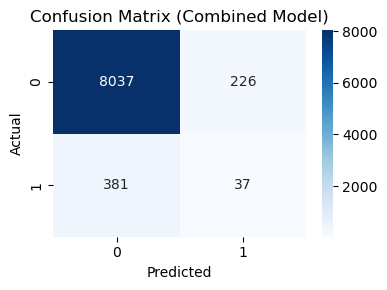

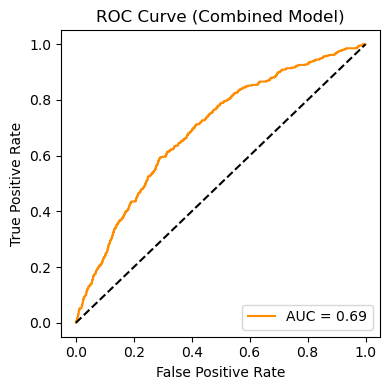

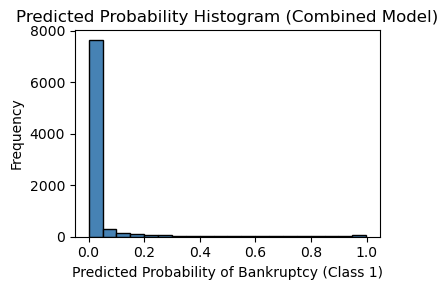

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from autogluon.tabular import TabularPredictor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load combined dataset
df_combined = pd.read_csv("../datasets/processed/processed_combined.csv")
target_col = 'Bankrupt' if 'Bankrupt' in df_combined.columns else 'bankrupt'

# Train-test split
X = df_combined.drop(columns=[target_col])
y = df_combined[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Apply PCA to preserve 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_res)
X_test_pca = pca.transform(X_test)

# Convert to DataFrame
pca_cols = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
df_train_pca = pd.DataFrame(X_train_pca, columns=pca_cols)
df_train_pca[target_col] = y_train_res.reset_index(drop=True)
df_test_pca = pd.DataFrame(X_test_pca, columns=pca_cols)

# Train AutoGluon model
output_path = "../autogluon_models/combined/"
os.makedirs(output_path, exist_ok=True)
predictor = TabularPredictor(label=target_col, path=output_path, verbosity=0)
predictor.fit(train_data=df_train_pca, presets="best_quality")

# Predictions
y_pred = predictor.predict(df_test_pca)
y_proba = predictor.predict_proba(df_test_pca)
proba_positive = y_proba[1] if isinstance(y_proba, pd.DataFrame) and 1 in y_proba.columns else y_proba.iloc[:, -1]

# Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Save metrics
metrics_df = pd.DataFrame({
    "accuracy": [acc],
    "precision": [prec],
    "recall": [rec],
    "f1_score": [f1]
})
metrics_df.to_csv(os.path.join(output_path, "metrics.csv"), index=False)

# Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix (Combined Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, proba_positive)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve (Combined Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "roc_curve.png"))
plt.show()

# Histogram of Probabilities
plt.figure(figsize=(4, 3))
plt.hist(proba_positive, bins=20, color="steelblue", edgecolor="black")
plt.title("Predicted Probability Histogram (Combined Model)")
plt.xlabel("Predicted Probability of Bankruptcy (Class 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "probability_histogram.png"))
plt.show()


In [ ]:
#!pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/e5/bb/dc75933de86e6076f58cf68325877be952a97a371c26b252013f1258a5a7/shap-0.47.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for slicer==0.0.8 from https://files.pythonhosted.org/packages/63/81/9ef641ff4e12cbcca30e54e72fb0951a2ba195d0cda0ba4100e532d929db/slicer-0.0.8-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/544.4 kB ? eta -:--:--
    --------------------------------------- 10.2/544.4 kB ? eta -:--:--
   -- ------------------------------------ 30.7/544.4 kB 435.7 kB/s eta 0:00:02
   -- ------------------------------------ 30.7/544.4 kB 435.7 kB/s eta 0:00:02
   ---- ---------------------------------- 61.4/544.4 kB 365.7 kB/s eta 0:00:02
   ----- --------------------------------- 81.9/544.4 kB 416.7 kB/s eta 0:00:02
   ------ -------------------------------- 92.2/544.